In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Company_Data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


Next, let's get a concise summary of the DataFrame, including the number of non-null values and data types of each column, and then check for basic descriptive statistics.

In [2]:
# Get information about the DataFrame, including data types and non-null values
df.info()

# Get descriptive statistics for numerical columns
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


Let's examine the unique values and their counts for the categorical columns: `ShelveLoc`, `Urban`, and `US`.

In [3]:
# Check unique values and their counts for 'ShelveLoc'
print("Unique values for ShelveLoc:\n", df['ShelveLoc'].value_counts())
print("\n")

# Check unique values and their counts for 'Urban'
print("Unique values for Urban:\n", df['Urban'].value_counts())
print("\n")

# Check unique values and their counts for 'US'
print("Unique values for US:\n", df['US'].value_counts())

Unique values for ShelveLoc:
 ShelveLoc
Medium    219
Bad        96
Good       85
Name: count, dtype: int64


Unique values for Urban:
 Urban
Yes    282
No     118
Name: count, dtype: int64


Unique values for US:
 US
Yes    258
No     142
Name: count, dtype: int64


As per the problem statement, we need to convert the continuous `Sales` variable into a categorical variable. Let's create a new categorical variable called `Sales_Category` where sales above the median are 'High' and sales below or equal to the median are 'Low'.

In [4]:
# Convert 'Sales' into a categorical variable
median_sales = df['Sales'].median()
df['Sales_Category'] = df['Sales'].apply(lambda x: 'High' if x > median_sales else 'Low')

# Display the value counts of the new 'Sales_Category' column
print("Value counts for Sales_Category:\n", df['Sales_Category'].value_counts())

# Drop the original 'Sales' column as it's no longer needed for the classification task
df = df.drop('Sales', axis=1)

display(df.head())

Value counts for Sales_Category:
 Sales_Category
Low     201
High    199
Name: count, dtype: int64


,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Sales_Category
0,138,73,11,276,120,Bad,42,17,Yes,Yes,High
1,111,48,16,260,83,Good,65,10,Yes,Yes,High
2,113,35,10,269,80,Medium,59,12,Yes,Yes,High
3,117,100,4,466,97,Medium,55,14,Yes,Yes,Low
4,141,64,3,340,128,Bad,38,13,Yes,No,Low


Now that we have our target categorical variable `Sales_Category`, we need to encode the remaining categorical features (`ShelveLoc`, `Urban`, `US`) into numerical format using one-hot encoding, as Random Forest models require numerical input.

In [5]:
# Apply one-hot encoding to categorical features: 'ShelveLoc', 'Urban', 'US'
df_encoded = pd.get_dummies(df, columns=['ShelveLoc', 'Urban', 'US'], drop_first=True)

# Display the first few rows of the encoded DataFrame
display(df_encoded.head())

# Display the info of the new DataFrame to see the updated columns and data types
df_encoded.info()

,CompPrice,Income,Advertising,Population,Price,Age,Education,Sales_Category,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,138,73,11,276,120,42,17,High,False,False,True,True
1,111,48,16,260,83,65,10,High,True,False,True,True
2,113,35,10,269,80,59,12,High,False,True,True,True
3,117,100,4,466,97,55,14,Low,False,True,True,True
4,141,64,3,340,128,38,13,Low,False,False,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CompPrice         400 non-null    int64 
 1   Income            400 non-null    int64 
 2   Advertising       400 non-null    int64 
 3   Population        400 non-null    int64 
 4   Price             400 non-null    int64 
 5   Age               400 non-null    int64 
 6   Education         400 non-null    int64 
 7   Sales_Category    400 non-null    object
 8   ShelveLoc_Good    400 non-null    bool  
 9   ShelveLoc_Medium  400 non-null    bool  
 10  Urban_Yes         400 non-null    bool  
 11  US_Yes            400 non-null    bool  
dtypes: bool(4), int64(7), object(1)
memory usage: 26.7+ KB


Now, let's prepare the data for our Random Forest model. This involves:
1. Separating the features (X) from the target variable (y).
2. Encoding the target variable `Sales_Category` into numerical labels.
3. Splitting the data into training and testing sets.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = df_encoded.drop('Sales_Category', axis=1)
y = df_encoded['Sales_Category']

# Encode the target variable 'Sales_Category' to numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("\nRandom Forest Classifier trained successfully!")

X_train shape: (280, 11)
X_test shape: (120, 11)
y_train shape: (280,)
y_test shape: (120,)

Random Forest Classifier trained successfully!


After training the model, let's evaluate its performance on the test set. We'll predict the `Sales_Category` for the test data and then check the accuracy and a detailed classification report.

In [7]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8083

Classification Report:
              precision    recall  f1-score   support

        High       0.83      0.82      0.82        65
         Low       0.79      0.80      0.79        55

    accuracy                           0.81       120
   macro avg       0.81      0.81      0.81       120
weighted avg       0.81      0.81      0.81       120



To understand which attributes cause high sales, we can examine the **feature importances** from our trained Random Forest model. This will tell us which features contributed most to the model's predictions.

/tmp/ipykernel_2609/64611090.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_features, y=top_5_features.index, palette='viridis')


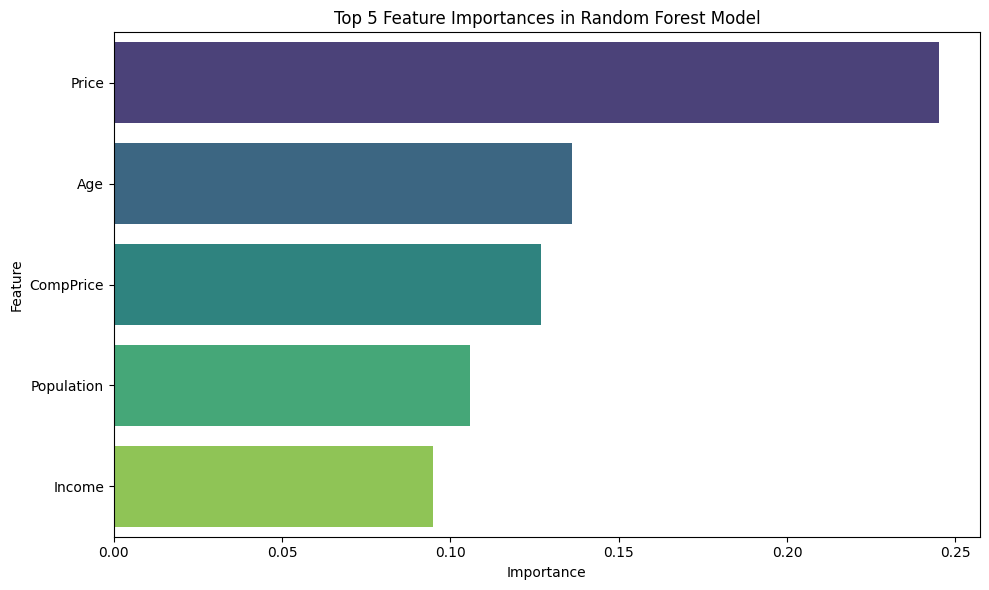

Top 5 Feature Importances:
 Price         0.245042
Age           0.136072
CompPrice     0.127008
Population    0.105755
Income        0.094835
dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort feature importances in descending order
sorted_feature_importances = feature_importances.sort_values(ascending=False)

# Select the top 5 most important features
top_5_features = sorted_feature_importances.head(5)

# Plot the top 5 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_features, y=top_5_features.index, palette='viridis')
plt.title('Top 5 Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 5 Feature Importances:\n", top_5_features)

To further evaluate the model's performance, especially in distinguishing between 'High' and 'Low' sales, let's generate and visualize a confusion matrix.

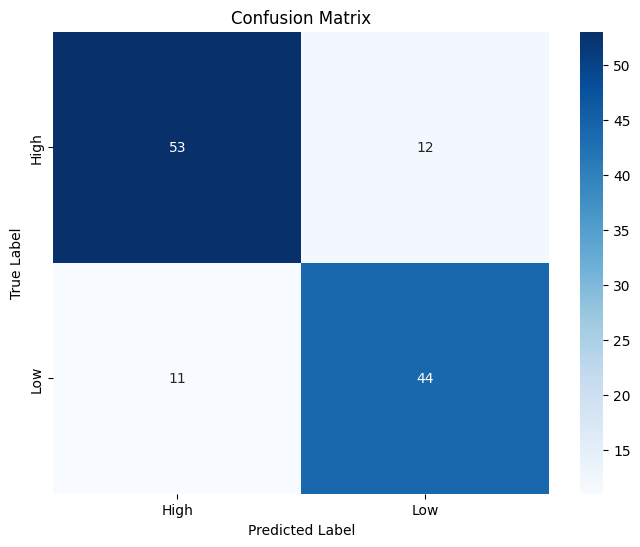

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get the class labels from the LabelEncoder
class_labels = le.classes_

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Hyperparameter Tuning with GridSearchCV

To further improve the model's performance and generalization, we will perform hyperparameter tuning using `GridSearchCV`. This will systematically search for the best combination of hyperparameters from a predefined grid.

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}
Best Cross-validation Score: 0.8179


In [12]:
# Evaluate the best model on the test set
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy on Test Set: {accuracy_tuned:.4f}")

print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

Tuned Model Accuracy on Test Set: 0.7750

Classification Report for Tuned Model:
              precision    recall  f1-score   support

        High       0.81      0.77      0.79        65
         Low       0.74      0.78      0.76        55

    accuracy                           0.78       120
   macro avg       0.77      0.78      0.77       120
weighted avg       0.78      0.78      0.78       120



### Feature Importance Comparison: Initial vs. Tuned Model

Let's compare the feature importances of the initial Random Forest model and the hyperparameter-tuned model to see if the tuning process changed the ranking or magnitude of feature contributions.

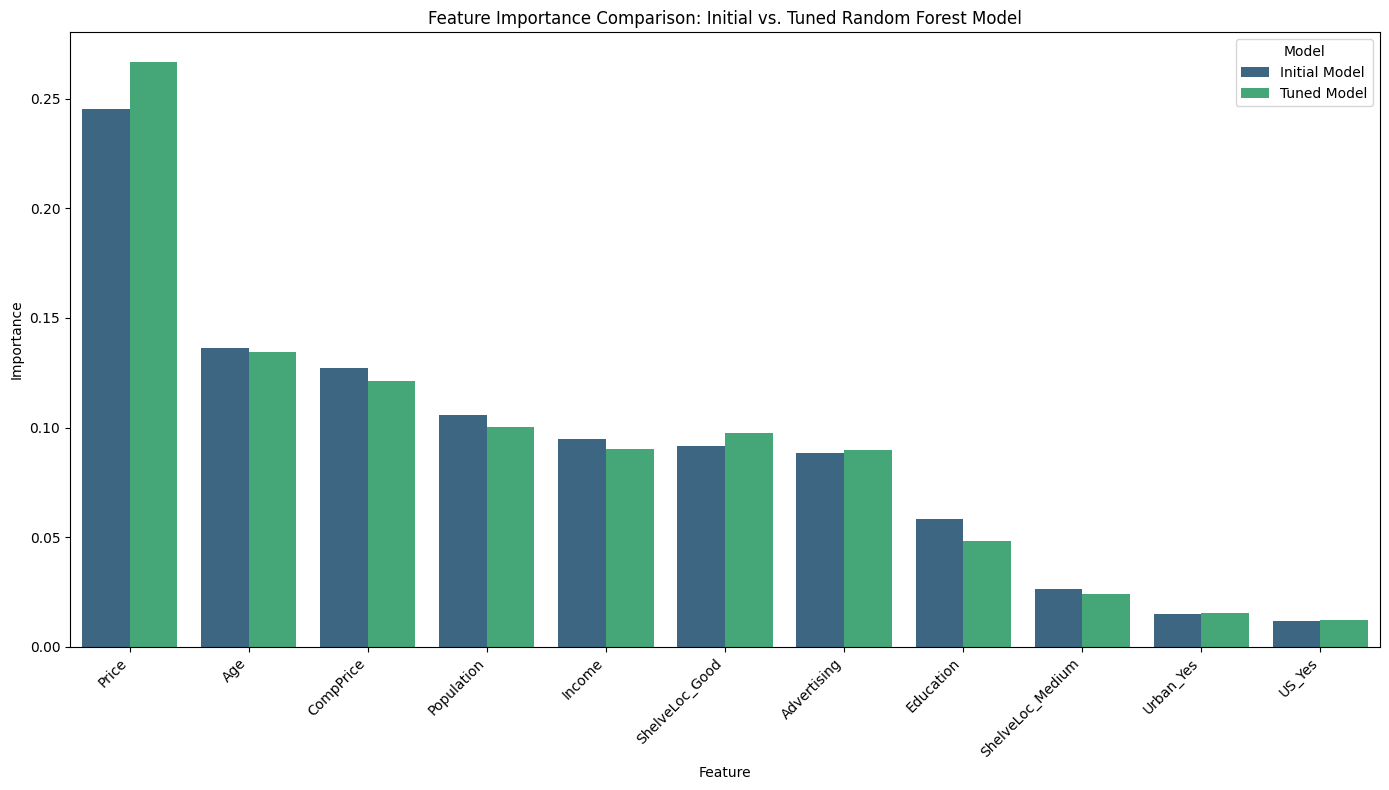

Feature Importances (Initial Model):
 Price               0.245042
Age                 0.136072
CompPrice           0.127008
Population          0.105755
Income              0.094835
ShelveLoc_Good      0.091569
Advertising         0.088450
Education           0.058188
ShelveLoc_Medium    0.026321
Urban_Yes           0.014865
dtype: float64

Feature Importances (Tuned Model):
 Price               0.266882
Age                 0.134337
CompPrice           0.121204
Population          0.100358
ShelveLoc_Good      0.097333
Income              0.090425
Advertising         0.089608
Education           0.048418
ShelveLoc_Medium    0.023942
Urban_Yes           0.015345
dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the initial Random Forest model
initial_feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Get feature importances from the tuned Random Forest model
tuned_feature_importances = pd.Series(best_rf_model.feature_importances_, index=X.columns)

# Create a DataFrame for comparison, ensuring common features are aligned
feature_importance_df = pd.DataFrame({
    'Initial Model': initial_feature_importances,
    'Tuned Model': tuned_feature_importances
}).sort_values(by='Initial Model', ascending=False)

# Melt the DataFrame for grouped bar plot
feature_importance_melted = feature_importance_df.reset_index().melt(id_vars='index', var_name='Model', value_name='Importance')
feature_importance_melted.rename(columns={'index': 'Feature'}, inplace=True)

# Plot the feature importances as a grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='Feature', y='Importance', hue='Model', data=feature_importance_melted, palette='viridis')
plt.title('Feature Importance Comparison: Initial vs. Tuned Random Forest Model')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

print("Feature Importances (Initial Model):\n", initial_feature_importances.sort_values(ascending=False).head(10))
print("\nFeature Importances (Tuned Model):\n", tuned_feature_importances.sort_values(ascending=False).head(10))

### Manual K-Fold Cross-Validation and Score Distribution

To get a more robust estimate of our model's performance and understand the variability of its accuracy across different data subsets, we will manually implement k-fold cross-validation. We'll use the best hyperparameters found by `GridSearchCV` for this evaluation.

In [15]:
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best parameters from GridSearchCV
best_params = grid_search.best_params_

# Initialize a KFold object
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# List to store accuracy scores for each fold
kfold_accuracies = []

# Perform K-fold cross-validation
print("Performing K-Fold Cross-Validation...")
for fold, (train_index, test_index) in enumerate(kf.split(X, y_encoded)):
    print(f"\n--- Fold {fold + 1}/{kf.n_splits} ---")
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y_encoded[train_index], y_encoded[test_index]

    # Initialize and train RandomForestClassifier with best parameters
    fold_rf_model = RandomForestClassifier(random_state=42, **best_params)
    fold_rf_model.fit(X_train_fold, y_train_fold)

    # Make predictions and calculate accuracy
    y_pred_fold = fold_rf_model.predict(X_test_fold)
    fold_accuracy = accuracy_score(y_test_fold, y_pred_fold)
    kfold_accuracies.append(fold_accuracy)

    print(f"Fold Accuracy: {fold_accuracy:.4f}")

# Print average accuracy and standard deviation
print("\n--- K-Fold Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(kfold_accuracies):.4f}")
print(f"Standard Deviation of Accuracy: {np.std(kfold_accuracies):.4f}")

Performing K-Fold Cross-Validation...

--- Fold 1/5 ---
Fold Accuracy: 0.8375

--- Fold 2/5 ---
Fold Accuracy: 0.8375

--- Fold 3/5 ---
Fold Accuracy: 0.7500

--- Fold 4/5 ---
Fold Accuracy: 0.8125

--- Fold 5/5 ---
Fold Accuracy: 0.8250

--- K-Fold Cross-Validation Results ---
Average Accuracy: 0.8125
Standard Deviation of Accuracy: 0.0326


/tmp/ipykernel_2609/1870420515.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(kfold_accuracies, kde=True, bins=3, palette='viridis')


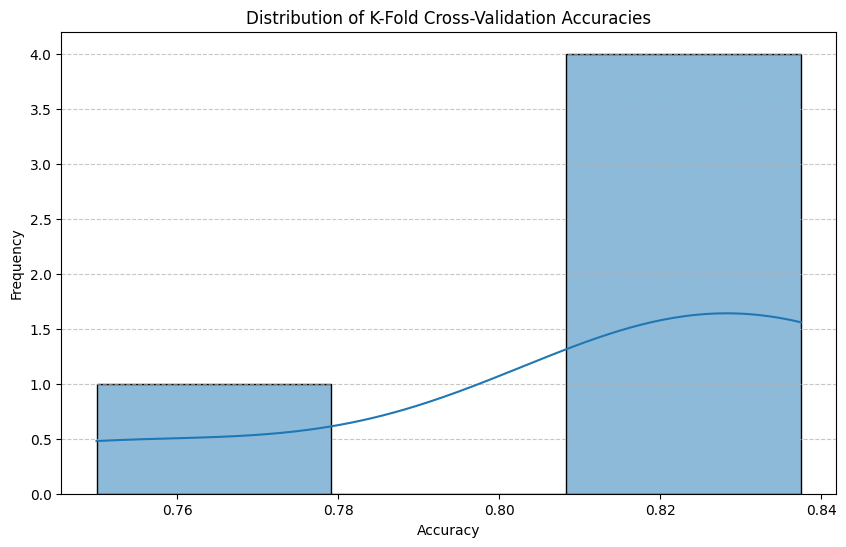

In [16]:
# Visualize the distribution of K-fold accuracies
plt.figure(figsize=(10, 6))
sns.histplot(kfold_accuracies, kde=True, bins=3, palette='viridis')
plt.title('Distribution of K-Fold Cross-Validation Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [17]:
import joblib

# Define the filename for the model
model_filename = 'random_forest_model.joblib'

# Save the best trained model to a file
joblib.dump(best_rf_model, model_filename)

print(f"Random Forest model saved to {model_filename}")

Random Forest model saved to random_forest_model.joblib
